In [28]:
import kagglehub

# path = kagglehub.dataset_download("muhammadfaizan65/hospital-infections-dataset")
# print("Path to dataset files:", path)

In [ ]:
import pandas as pd
import os

# Paste your dataset path here
my_path = ''
path = '/datasets/muhammadfaizan65/hospital-infections-dataset/versions/1'
files = os.listdir(path)
print(files)

df = pd.read_csv(os.path.join(path, files[0]))

['Healthcare_Associated_Infections_-_Hospital.csv']


The **Hospital Infections** dataset contains comprehensive information about infection measures and performance indicators for various hospitals.

This data includes details about the hospitals, such as their locations, infection measure types, performance scores, and comparisons to national benchmarks. 

The dataset is useful for analyzing hospital performance regarding infection control and prevention.

In [30]:
df.shape

(222864, 16)

In [31]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit,
    StratifiedGroupKFold,
    GroupKFold,
    cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    make_scorer
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization, LeakyReLU, ELU
from tensorflow.keras.regularizers import l1, l2, l1_l2
from sklearn.utils.class_weight import compute_class_weight
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
import shap


SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [32]:
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
df.columns

Index(['provider_id', 'hospital_name', 'address', 'city', 'state', 'zip_code',
       'county_name', 'phone_number', 'measure_name', 'measure_id',
       'compared_to_national', 'score', 'footnote', 'measure_start_date',
       'measure_end_date', 'location'],
      dtype='object')

In [10]:
df

,provider_id,hospital_name,address,city,state,zip_code,county_name,phone_number,measure_name,measure_id,compared_to_national,score,footnote,measure_start_date,measure_end_date,location
0,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI: Lower Confidence Limit,HAI_1_CI_LOWER,No Different than National Benchmark,0.165,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n"
1,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI: Upper Confidence Limit,HAI_1_CI_UPPER,No Different than National Benchmark,3.249,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n"
2,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI: Number of Procedures,HAI_1_DOPC_DAYS,No Different than National Benchmark,1485,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n"
3,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI: Predicted Cases,HAI_1_ELIGCASES,No Different than National Benchmark,2.034,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n"
4,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI: Observed Cases,HAI_1_NUMERATOR,No Different than National Benchmark,2,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222859,351325,ST LUKE'S HOSPITAL,702 1ST ST SW,CROSBY,ND,58730,DIVIDE,7019656384,CAUTI: Observed Cases,HAI_2_NUMERATOR,Not Available,Not Available,5 - Results are not available for this reporti...,01/01/2015,06/30/2015,"702 1ST ST SW\nCROSBY, ND 58730\n(48.906708, -..."
222860,471303,NORTHEASTERN VERMONT REGIONAL HOSPITAL,1315 HOSPITAL DRIVE,SAINT JOHNSBURY,VT,5819,CALEDONIA,8027487400,C.diff Lower Confidence Limit,HAI_6_CI_LOWER,Not Available,Not Available,5 - Results are not available for this reporti...,07/01/2014,06/30/2015,"1315 HOSPITAL DRIVE\nSAINT JOHNSBURY, VT 05819..."
222861,150026,IU HEALTH GOSHEN HOSPITAL,200 HIGH PARK AVE,GOSHEN,IN,46526,ELKHART,5743641000,CLABSI: Number of Procedures,HAI_1_DOPC_DAYS,No Different than National Benchmark,1416,NaN,01/01/2015,06/30/2015,"200 HIGH PARK AVE\nGOSHEN, IN 46526\n(41.56432..."
222862,50038,SANTA CLARA VALLEY MEDICAL CENTER,751 SOUTH BASCOM AVENUE,SAN JOSE,CA,95128,SANTA CLARA,4088855000,SSI: Colon Predicted Cases,HAI_3_ELIGCASES,Worse than the National Benchmark,3.246,NaN,07/01/2014,06/30/2015,"751 SOUTH BASCOM AVENUE\nSAN JOSE, CA 95128\n(..."


For classification I'm choosing a column to predict.

The choice of 'compared_to_national' is convenient because this column describes the result directly: whether the measurement result is worse, the same or better than the national benchmark.

In [33]:
target_col = "compared_to_national"

print("Kolumna celu:", target_col)
print("Wartości targetu:")
display(df[target_col].astype(str).value_counts(dropna=False))

Kolumna celu: compared_to_national
Wartości targetu:


compared_to_national
Not Available                           121398
No Different than National Benchmark     78324
Better than the National Benchmark       18108
Worse than the National Benchmark         5034
Name: count, dtype: int64

Mapping target onto numerical classes:

In [34]:
def normalize_compared_to_national(x):
    s = str(x).strip().lower()
    if s in ["nan", "none", ""]:
        return np.nan
    if "better" in s:
        return "better"
    if "no different" in s:
        return "same"
    if "worse" in s:
        return "worse"
    return s

df = df.copy()
df[target_col] = df[target_col].apply(normalize_compared_to_national)
df = df.dropna(subset=[target_col]).reset_index(drop=True)

classes = df[target_col].unique()
print("Normalised classes:", classes)

class_map = {label: idx for idx, label in enumerate(classes)}
df[target_col] = df[target_col].map(class_map).astype(int)

print("Class mapping")
print(class_map)

display(df[target_col].value_counts().sort_index())

Normalised classes: ['same' 'worse' 'better' 'not available']
Class mapping
{'same': 0, 'worse': 1, 'better': 2, 'not available': 3}


compared_to_national
0     78324
1      5034
2     18108
3    121398
Name: count, dtype: int64

In [9]:
df

,provider_id,hospital_name,address,city,state,zip_code,county_name,phone_number,measure_name,measure_id,compared_to_national,score,footnote,measure_start_date,measure_end_date,location
0,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI: Lower Confidence Limit,HAI_1_CI_LOWER,0,0.165,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n"
1,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI: Upper Confidence Limit,HAI_1_CI_UPPER,0,3.249,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n"
2,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI: Number of Procedures,HAI_1_DOPC_DAYS,0,1485,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n"
3,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI: Predicted Cases,HAI_1_ELIGCASES,0,2.034,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n"
4,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI: Observed Cases,HAI_1_NUMERATOR,0,2,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222859,351325,ST LUKE'S HOSPITAL,702 1ST ST SW,CROSBY,ND,58730,DIVIDE,7019656384,CAUTI: Observed Cases,HAI_2_NUMERATOR,3,Not Available,5 - Results are not available for this reporti...,01/01/2015,06/30/2015,"702 1ST ST SW\nCROSBY, ND 58730\n(48.906708, -..."
222860,471303,NORTHEASTERN VERMONT REGIONAL HOSPITAL,1315 HOSPITAL DRIVE,SAINT JOHNSBURY,VT,5819,CALEDONIA,8027487400,C.diff Lower Confidence Limit,HAI_6_CI_LOWER,3,Not Available,5 - Results are not available for this reporti...,07/01/2014,06/30/2015,"1315 HOSPITAL DRIVE\nSAINT JOHNSBURY, VT 05819..."
222861,150026,IU HEALTH GOSHEN HOSPITAL,200 HIGH PARK AVE,GOSHEN,IN,46526,ELKHART,5743641000,CLABSI: Number of Procedures,HAI_1_DOPC_DAYS,0,1416,NaN,01/01/2015,06/30/2015,"200 HIGH PARK AVE\nGOSHEN, IN 46526\n(41.56432..."
222862,50038,SANTA CLARA VALLEY MEDICAL CENTER,751 SOUTH BASCOM AVENUE,SAN JOSE,CA,95128,SANTA CLARA,4088855000,SSI: Colon Predicted Cases,HAI_3_ELIGCASES,1,3.246,NaN,07/01/2014,06/30/2015,"751 SOUTH BASCOM AVENUE\nSAN JOSE, CA 95128\n(..."


INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222864 entries, 0 to 222863
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   provider_id           222864 non-null  int64 
 1   hospital_name         222864 non-null  object
 2   address               222864 non-null  object
 3   city                  222864 non-null  object
 4   state                 222864 non-null  object
 5   zip_code              222864 non-null  int64 
 6   county_name           222240 non-null  object
 7   phone_number          222864 non-null  int64 
 8   measure_name          222864 non-null  object
 9   measure_id            222864 non-null  object
 10  compared_to_national  222864 non-null  int64 
 11  score                 222864 non-null  object
 12  footnote              141684 non-null  object
 13  measure_start_date    222864 non-null  object
 14  measure_end_date      222864 non-null  object
 15  location   

,count,mean,std,min,25%,50%,75%,max
provider_id,222864.0,2.663545e+05,1.556219e+05,10001.0,1.401770e+05,2.513360e+05,3.901380e+05,6.701070e+05
zip_code,222864.0,5.372634e+04,2.690501e+04,603.0,3.280600e+04,5.500900e+04,7.570100e+04,9.992900e+04
phone_number,222864.0,5.844578e+09,2.332326e+09,936933841.0,3.867199e+09,6.038823e+09,7.877276e+09,9.898943e+09
compared_to_national,222864.0,1.819244e+00,1.392987e+00,0.0,0.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00



% of lacking elems


,missing_%
footnote,36.425802
county_name,0.279991


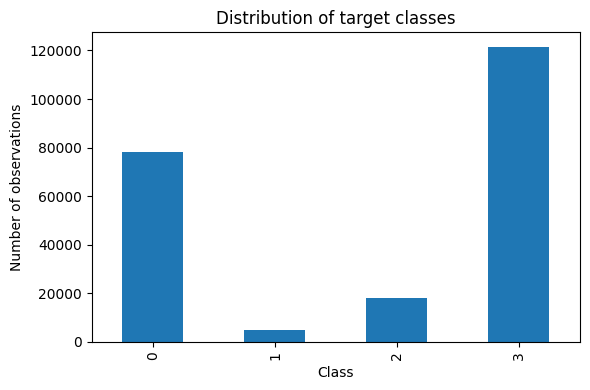

In [15]:
print("INFO:")
df.info()

print("\nStatistical description of numerical columns")
display(df.describe().T)

print("\n% of lacking elems")
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct[missing_pct > 0].to_frame("missing_%"))

plt.figure(figsize=(6, 4))
df[target_col].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of target classes")
plt.xlabel("Class")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()

Due to the strong class imbalance and the presence of the 'not available'(=3) category, which lacks clear comparative information, I decided to solve the task of a binary classification. A positive class represents better cases, while a negative class represents same and worse cases. This approach simplifies the problem, increases training stability, and allows for more reliable model evaluation.

I will take better and same+worse as binary target to even the numbers a bit.

In [35]:
df = df[df[target_col] != 3].copy()

# better (2) -> 1
# same (0) + worse (1) -> 0
df["target_binary"] = (df[target_col] == 2).astype(int)

print("Class distribution after binarization:")
display(df["target_binary"].value_counts().rename(index={0: "not_better", 1: "better"}))

print("\nPositive class share (better):", round(df["target_binary"].mean(), 4))

Class distribution after binarization:


target_binary
not_better    83358
better        18108
Name: count, dtype: int64


Positive class share (better): 0.1785


The dataset of course is still imbalanced, with only ~18% of observations belonging to the positive class (“better”).

In [12]:
df.head(10)

,provider_id,hospital_name,address,city,state,zip_code,county_name,phone_number,measure_name,measure_id,compared_to_national,score,footnote,measure_start_date,measure_end_date,location,target_binary
0,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI: Lower Confidence Limit,HAI_1_CI_LOWER,0,0.165,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n",0
1,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI: Upper Confidence Limit,HAI_1_CI_UPPER,0,3.249,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n",0
2,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI: Number of Procedures,HAI_1_DOPC_DAYS,0,1485,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n",0
3,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI: Predicted Cases,HAI_1_ELIGCASES,0,2.034,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n",0
4,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI: Observed Cases,HAI_1_NUMERATOR,0,2,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n",0
5,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,Central line-associated bloodstream infections...,HAI_1_SIR,0,0.983,NaN,01/01/2015,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n",0
6,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI Lower Confidence Limit,HAI_1a_CI_LOWER,1,1.168,NaN,07/01/2014,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n",0
7,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI Upper Confidence Limit,HAI_1a_CI_UPPER,1,7.068,NaN,07/01/2014,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n",0
8,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI Central Line Days,HAI_1a_DOPC_DAYS,1,1045,NaN,07/01/2014,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n",0
9,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,CLABSI Predicted Cases,HAI_1a_ELIGCASES,1,1.568,NaN,07/01/2014,06/30/2015,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL 35957\n",0


In [36]:
target = 'target_binary'
features = [col for col in df.columns if col != target and col != 'compared_to_national']
numeric_features = df[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df[features].select_dtypes(include=['object', 'bool']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print(f"\nTotal features used: {len(features)}")

Numeric features: ['provider_id', 'zip_code', 'phone_number']
Categorical features: ['hospital_name', 'address', 'city', 'state', 'county_name', 'measure_name', 'measure_id', 'score', 'footnote', 'measure_start_date', 'measure_end_date', 'location']

Total features used: 15


I think that out of all features we could take, only 3 make sense:
1) state - geographic context
2) measure_name - what exactly is being measured
3) score - the actual numerical value of the measurement

In [37]:
columns_to_keep = ['state', 'measure_name', 'score']
features = columns_to_keep

print(features)
print(f"\nShape before dropping: {df.shape}")

df = df[features + ['target_binary']].copy()
print(f"Shape after dropping junk columns: {df.shape}")
display(df.head())

['state', 'measure_name', 'score']

Shape before dropping: (101466, 17)
Shape after dropping junk columns: (101466, 4)


,state,measure_name,score,target_binary
0,AL,CLABSI: Lower Confidence Limit,0.165,0
1,AL,CLABSI: Upper Confidence Limit,3.249,0
2,AL,CLABSI: Number of Procedures,1485,0
3,AL,CLABSI: Predicted Cases,2.034,0
4,AL,CLABSI: Observed Cases,2,0


In [38]:
numeric_features = df[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df[features].select_dtypes(include=['object', 'bool']).columns.tolist()

Now I do 80/20 stratified split so both sets keep the same class ratio

In [39]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=SEED
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Train positive ratio: {y_train.mean():.1%}")
print(f"Test positive ratio : {y_test.mean():.1%}")

Train shape: (81172, 3) | Test shape: (20294, 3)
Train positive ratio: 17.8%
Test positive ratio : 17.8%


Now I'm building a pipeline that handles missing values, scaling and encoding

In [40]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

Keeping in mind that classes are imbalanced, evaluating function might help with accuracy alone being misleading

In [41]:
def evaluate_model(y_true, y_pred, y_proba=None, model_name="Model"):
    print(f"\n=== {model_name} RESULTS ===")
    print(classification_report(y_true, y_pred, digits=4))
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()
    
    if y_proba is not None:
        from sklearn.metrics import roc_auc_score
        print(f"ROC-AUC: {roc_auc_score(y_true, y_proba):.4f}")

In [42]:
models = {}

models['Logistic'] = LogisticRegression(
    class_weight='balanced', 
    max_iter=1000, 
    random_state=SEED
)

models['RandomForest'] = RandomForestClassifier(
    n_estimators=200, 
    max_depth=8, 
    class_weight='balanced', 
    random_state=SEED
)

if XGBOOST_AVAILABLE:
    pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
    models['XGBoost'] = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=pos_weight,
        random_state=SEED,
        eval_metric='auc'
    )

Fit each model on the pipeline + evaluate


Training Logistic...

=== Logistic RESULTS ===
              precision    recall  f1-score   support

           0     0.9293    0.7270    0.8158     16672
           1     0.3724    0.7454    0.4966      3622

    accuracy                         0.7303     20294
   macro avg     0.6508    0.7362    0.6562     20294
weighted avg     0.8299    0.7303    0.7589     20294



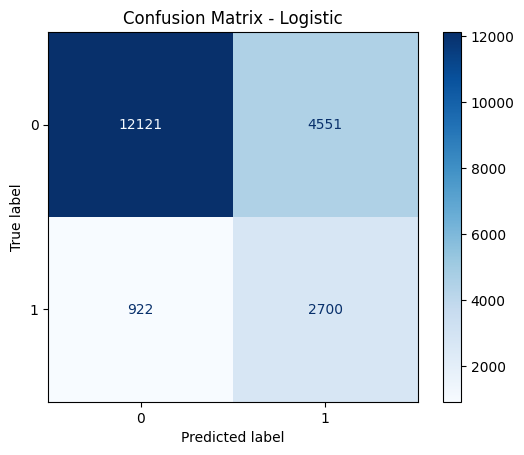

ROC-AUC: 0.8159

Training RandomForest...

=== RandomForest RESULTS ===
              precision    recall  f1-score   support

           0     0.9139    0.5432    0.6814     16672
           1     0.2667    0.7645    0.3954      3622

    accuracy                         0.5827     20294
   macro avg     0.5903    0.6539    0.5384     20294
weighted avg     0.7984    0.5827    0.6304     20294



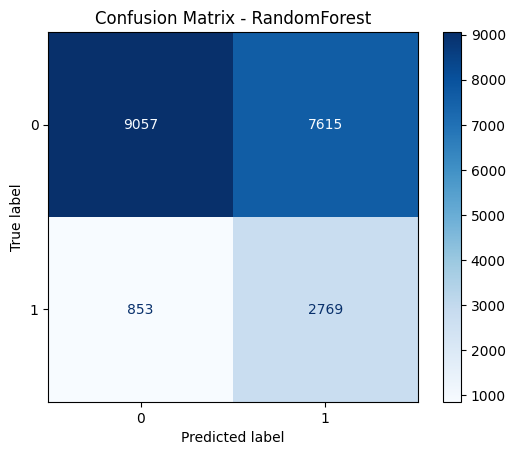

ROC-AUC: 0.7063

Training XGBoost...

=== XGBoost RESULTS ===
              precision    recall  f1-score   support

           0     0.9265    0.4765    0.6293     16672
           1     0.2553    0.8261    0.3900      3622

    accuracy                         0.5389     20294
   macro avg     0.5909    0.6513    0.5097     20294
weighted avg     0.8067    0.5389    0.5866     20294



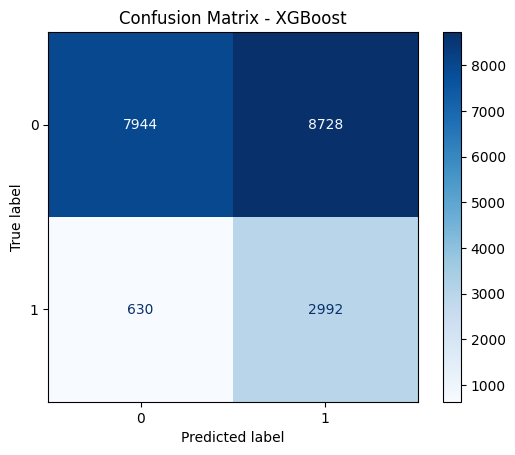

ROC-AUC: 0.7059


In [20]:
for name, model in models.items():
    print(f"\nTraining {name}...")
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe[-1], "predict_proba") else None
    
    evaluate_model(y_test, y_pred, y_proba, name)
    
    # saving the best model for later
    if name == 'XGBoost' or name == 'RandomForest':
        best_pipe = pipe

ANN with class weights

E0000 00:00:1774789617.640347    6358 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - accuracy: 0.6034 - auc: 0.7028 - loss: 0.6274 - val_accuracy: 0.6663 - val_auc: 0.7757 - val_loss: 0.5661
Epoch 2/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.7433 - auc: 0.8613 - loss: 0.4587 - val_accuracy: 0.7072 - val_auc: 0.8113 - val_loss: 0.5128
Epoch 3/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8108 - auc: 0.9284 - loss: 0.3309 - val_accuracy: 0.7203 - val_auc: 0.8167 - val_loss: 0.5414
Epoch 4/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8403 - auc: 0.9502 - loss: 0.2740 - val_accuracy: 0.7148 - val_auc: 0.8154 - val_loss: 0.5872
Epoch 5/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 79ms/step - accuracy: 0.8531 - auc: 0.9599 - loss: 0.2429 - val_accuracy: 0.7273 - val_auc: 0.8114 - val_loss: 0.6109
Epoch 6/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.8656 - auc: 0.9659 - loss: 0.2243 - val_accuracy: 0.7224 - val_auc: 0.8095 - val_loss: 0.6751
Epoch 7/50
159/159 ━━━━━━━━━

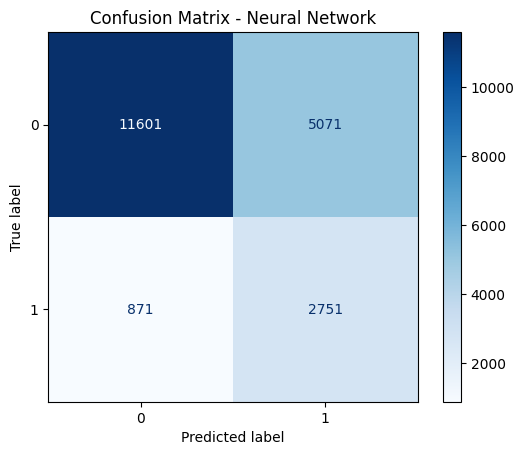

ROC-AUC: 0.8113


In [21]:
X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp  = preprocessor.transform(X_test)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

model_nn = keras.Sequential([
    layers.Input(shape=(X_train_pp.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_nn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

history = model_nn.fit(
    X_train_pp, y_train,
    validation_data=(X_test_pp, y_test),
    epochs=50,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

# evaluating
y_pred_nn = (model_nn.predict(X_test_pp) > 0.5).astype(int).flatten()
y_proba_nn = model_nn.predict(X_test_pp).flatten()
evaluate_model(y_test, y_pred_nn, y_proba_nn, "Neural Network")

We get such results:

|     Model     | Accuracy      | F1            | ROC-AUC       | 
| ------------- |:-------------:|:-------------:|:-------------:|
| Logistic      | 73.0%         | 0.4966        | 0.8159        |
| Neural Network| 70.7%         | 0.4808        | 0.8113        |
| Random Forest | 58.3%         | 0.3954        | 0.7063        |
| XGBoost       | 53.9%         | 0.3900        | 0.7059        |

Tree-based models are performing weaker, as now I have only 3 features, so there's nothing to split on.

I'll try to give Random Forest and XGBoost one more chance to see if sth can be improved;

If it won't work, I'll proceed experimenting with Logistic and Neural Network models.

Firstly, for the Random Forest, I'll try getting more and shallower trees to reduce overfitting, balanced subsample and min_samples_leaf for better generalization, and feature subsampling (max_features) to reduce correlation between trees

In [25]:
rf_results = []

pipe_rf_orig = Pipeline(steps=[('preprocessor', preprocessor), 
                               ('classifier', models['RandomForest'])])
pipe_rf_orig.fit(X_train, y_train)
y_pred = pipe_rf_orig.predict(X_test)
rf_results.append({'name': 'RF Original', 
                   'f1': f1_score(y_test, y_pred), 
                   'roc': roc_auc_score(y_test, pipe_rf_orig.predict_proba(X_test)[:,1])})

rf1 = RandomForestClassifier(n_estimators=400, max_depth=6, 
                             class_weight='balanced', random_state=SEED)
pipe = Pipeline([('preprocessor', preprocessor), ('classifier', rf1)])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
rf_results.append({'name': 'RF1: More trees + shallower', 
                   'f1': f1_score(y_test, y_pred), 
                   'roc': roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1])})

rf2 = RandomForestClassifier(n_estimators=200, max_depth=8, 
                             min_samples_leaf=5, class_weight='balanced', 
                             random_state=SEED)
pipe = Pipeline([('preprocessor', preprocessor), ('classifier', rf2)])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
rf_results.append({'name': 'RF2: min_samples_leaf + balanced', 
                   'f1': f1_score(y_test, y_pred), 
                   'roc': roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1])})

rf3 = RandomForestClassifier(n_estimators=300, max_depth=7, 
                             max_features=0.7, class_weight='balanced', 
                             random_state=SEED)
pipe = Pipeline([('preprocessor', preprocessor), ('classifier', rf3)])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
rf_results.append({'name': 'RF3: max_features=0.7', 
                   'f1': f1_score(y_test, y_pred), 
                   'roc': roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1])})

rf_df = pd.DataFrame(rf_results)
display(rf_df.round(4))

,name,f1,roc
0,RF Original,0.3954,0.7063
1,RF1: More trees + shallower,0.3988,0.7088
2,RF2: min_samples_leaf + balanced,0.3969,0.7074
3,RF3: max_features=0.7,0.3509,0.6004


And now for the XGBoost; I'll try lower learning rate and more trees to reduce overfitting overfitting, adding regularization (gamma + subsample), and shallower trees with colsample to reduce complexity

In [26]:
xgb_results = []

pipe_xgb_orig = Pipeline(steps=[('preprocessor', preprocessor), 
                                ('classifier', models['XGBoost'])])
pipe_xgb_orig.fit(X_train, y_train)
y_pred = pipe_xgb_orig.predict(X_test)
xgb_results.append({'name': 'XGBoost Original', 
                    'f1': f1_score(y_test, y_pred), 
                    'roc': roc_auc_score(y_test, pipe_xgb_orig.predict_proba(X_test)[:,1])})

xgb1 = XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                     scale_pos_weight=pos_weight, random_state=SEED, eval_metric='auc')
pipe = Pipeline([('preprocessor', preprocessor), ('classifier', xgb1)])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
xgb_results.append({'name': 'XGB1: Lower LR + more trees', 
                    'f1': f1_score(y_test, y_pred), 
                    'roc': roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1])})

xgb2 = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.08,
                     gamma=0.5, subsample=0.8, scale_pos_weight=pos_weight, 
                     random_state=SEED, eval_metric='auc')
pipe = Pipeline([('preprocessor', preprocessor), ('classifier', xgb2)])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
xgb_results.append({'name': 'XGB2: Added gamma + subsample', 
                    'f1': f1_score(y_test, y_pred), 
                    'roc': roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1])})

xgb3 = XGBClassifier(n_estimators=350, max_depth=4, learning_rate=0.1,
                     colsample_bytree=0.7, scale_pos_weight=pos_weight, 
                     random_state=SEED, eval_metric='auc')
pipe = Pipeline([('preprocessor', preprocessor), ('classifier', xgb3)])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
xgb_results.append({'name': 'XGB3: Shallower + colsample', 
                    'f1': f1_score(y_test, y_pred), 
                    'roc': roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1])})

xgb_df = pd.DataFrame(xgb_results)
display(xgb_df.round(4))

,name,f1,roc
0,XGBoost Original,0.3900,0.7059
1,XGB1: Lower LR + more trees,0.3898,0.7041
2,XGB2: Added gamma + subsample,0.3938,0.7101
3,XGB3: Shallower + colsample,0.3917,0.7081


I'll continue with NN and Logistic. 

Trying a hyperparameter experiment (changing one at a time)

In [22]:
for neurons in [64, 128, 256]:
    model_test = keras.Sequential([
        layers.Input(shape=(X_train_pp.shape[1],)),
        layers.Dense(neurons, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model_test.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model_test.fit(X_train_pp, y_train, epochs=20, batch_size=512, verbose=0, class_weight=class_weight_dict)
    score = model_test.evaluate(X_test_pp, y_test, verbose=0)[1]
    print(f"Neurons={neurons} -> Test accuracy: {score:.4f}")

Neurons=64 -> Test accuracy: 0.7391
Neurons=128 -> Test accuracy: 0.7485
Neurons=256 -> Test accuracy: 0.7283


At neurons=256 model seemingly starts to overfit.

Now I'll test different number of layers, dropout rates, and learning rates

In [27]:
results = []

for layers_count in [1, 2, 3]:
    for dropout_rate in [0.2, 0.3, 0.4]:
        for lr in [0.001, 0.0005]:
            
            model_test = keras.Sequential()
            model_test.add(layers.Input(shape=(X_train_pp.shape[1],)))
            
            for _ in range(layers_count):
                model_test.add(layers.Dense(128, activation='relu'))
                model_test.add(layers.Dropout(dropout_rate))
            
            model_test.add(layers.Dense(32, activation='relu'))
            model_test.add(layers.Dense(1, activation='sigmoid'))
            
            model_test.compile(
                optimizer=keras.optimizers.Adam(learning_rate=lr),
                loss='binary_crossentropy',
                metrics=['accuracy', keras.metrics.AUC(name='auc')]
            )
            
            history = model_test.fit(
                X_train_pp, y_train,
                validation_data=(X_test_pp, y_test),
                epochs=30,
                batch_size=512,
                class_weight=class_weight_dict,
                callbacks=[EarlyStopping(patience=8, restore_best_weights=True)],
                verbose=0
            )
            
            y_pred_test = (model_test.predict(X_test_pp, verbose=0) > 0.5).astype(int).flatten()
            y_proba_test = model_test.predict(X_test_pp, verbose=0).flatten()
            
            f1 = f1_score(y_test, y_pred_test)
            roc = roc_auc_score(y_test, y_proba_test)
            
            results.append({
                'layers': layers_count,
                'dropout': dropout_rate,
                'lr': lr,
                'f1': round(f1, 4),
                'roc_auc': round(roc, 4)
            })

tuning_df = pd.DataFrame(results)
display(tuning_df.sort_values('f1', ascending=False).head(10))

,layers,dropout,lr,f1,roc_auc
11,2,0.4,0.0005,0.4898,0.8166
1,1,0.2,0.0005,0.4863,0.8186
0,1,0.2,0.0010,0.4833,0.8169
12,3,0.2,0.0010,0.4823,0.8112
5,1,0.4,0.0005,0.4815,0.8167
3,1,0.3,0.0005,0.4812,0.8160
6,2,0.2,0.0010,0.4805,0.8124
16,3,0.4,0.0010,0.4795,0.8106
13,3,0.2,0.0005,0.4775,0.8124
8,2,0.3,0.0010,0.4758,0.8120


The little positive shift is present, but better results would be preferable.

I'll try to test BatchNorm + ReLU/LeakyReLU/ELU

In [29]:
results_bn = []

for activation in ['relu', 'leakyrelu', 'elu']:
    for use_bn in [False, True]:
        
        model_test = keras.Sequential()
        model_test.add(layers.Input(shape=(X_train_pp.shape[1],)))
        
        model_test.add(layers.Dense(128))
        if use_bn:
            model_test.add(BatchNormalization())
        if activation == 'leakyrelu':
            model_test.add(LeakyReLU(alpha=0.1))
        elif activation == 'elu':
            model_test.add(ELU())
        else:
            model_test.add(layers.Activation('relu'))
        model_test.add(layers.Dropout(0.3))
        
        model_test.add(layers.Dense(64))
        if use_bn:
            model_test.add(BatchNormalization())
        if activation == 'leakyrelu':
            model_test.add(LeakyReLU(alpha=0.1))
        elif activation == 'elu':
            model_test.add(ELU())
        else:
            model_test.add(layers.Activation('relu'))
        model_test.add(layers.Dropout(0.3))
        
        model_test.add(layers.Dense(1, activation='sigmoid'))
        
        model_test.compile(optimizer=keras.optimizers.Adam(0.0005),
                           loss='binary_crossentropy',
                           metrics=['accuracy', keras.metrics.AUC(name='auc')])
        
        history = model_test.fit(
            X_train_pp, y_train,
            validation_data=(X_test_pp, y_test),
            epochs=40,
            batch_size=512,
            class_weight=class_weight_dict,
            callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
            verbose=0
        )
        
        y_pred = (model_test.predict(X_test_pp, verbose=0) > 0.5).astype(int).flatten()
        f1 = f1_score(y_test, y_pred)
        
        results_bn.append({
            'activation': activation,
            'batch_norm': use_bn,
            'f1': round(f1, 4)
        })

pd.DataFrame(results_bn).sort_values('f1', ascending=False)

/home/sofia/stored_data/ggsn/venvvv/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/home/sofia/stored_data/ggsn/venvvv/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


,activation,batch_norm,f1
1,relu,True,0.4862
3,leakyrelu,True,0.4843
2,leakyrelu,False,0.4822
0,relu,False,0.4816
4,elu,False,0.4749
5,elu,True,0.4564


I'll keep looking for ways to improve with keeping relu activation and batch normalization.

It might be a good idea to experiment with regularisation.

In [32]:
results_reg = []

for reg_type in ['l1', 'l2', 'l1_l2']:
    for strength in [0.0001, 0.001, 0.01]:
        
        reg = None
        if reg_type == 'l1':
            reg = l1(strength)
        elif reg_type == 'l2':
            reg = l2(strength)
        else:
            reg = l1_l2(l1=strength, l2=strength)
    

        model_test = keras.Sequential([
            layers.Input(shape=(X_train_pp.shape[1],)),
            
            layers.Dense(128, activation='relu', kernel_regularizer=reg),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            
            layers.Dense(64, activation='relu', kernel_regularizer=reg),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            
            layers.Dense(1, activation='sigmoid')
        ])
        
        model_test.compile(optimizer=keras.optimizers.Adam(0.0005),
                           loss='binary_crossentropy',
                           metrics=['accuracy', keras.metrics.AUC(name='auc')])
        
        history = model_test.fit(
            X_train_pp, y_train,
            validation_data=(X_test_pp, y_test),
            epochs=40,
            batch_size=512,
            class_weight=class_weight_dict,
            callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
            verbose=0
        )
        
        y_pred = (model_test.predict(X_test_pp, verbose=0) > 0.5).astype(int).flatten()
        f1 = f1_score(y_test, y_pred)
        
        results_reg.append({
            'regularization': reg_type,
            'strength': strength,
            'f1': round(f1, 4)
        })

pd.DataFrame(results_reg).sort_values('f1', ascending=False)

,regularization,strength,f1
3,l2,0.0001,0.4814
5,l2,0.0100,0.4733
0,l1,0.0001,0.4683
1,l1,0.0010,0.4653
7,l1_l2,0.0010,0.4546
6,l1_l2,0.0001,0.4543
2,l1,0.0100,0.3913
8,l1_l2,0.0100,0.3856
4,l2,0.0010,0.3725


Even though I got decent results with Logistic Regression and the Neural Network, I couldn't help but notice how tree-based models are underperforming. I want to try experimenting with preprocessing, adding some other features and doing a group-aware split.

In [43]:
df = pd.read_csv(os.path.join(path, files[0]))
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
def normalize_compared_to_national(x):
    s = str(x).strip().lower()
    if "better" in s:
        return "better"
    if "no different" in s:
        return "same"
    if "worse" in s:
        return "worse"
    return "not_available"
df["compared_to_national"] = df["compared_to_national"].apply(normalize_compared_to_national)

df["score"] = pd.to_numeric(df["score"], errors="coerce")
df = df[df["compared_to_national"] != "not_available"].copy().reset_index(drop=True)
df["target_binary"] = (df["compared_to_national"] == "better").astype(int)

features = ["state", "measure_name", "measure_id", "county_name", "score"]

X = df[features].copy()
y = df["target_binary"].copy()
groups = df["provider_id"]   # for grouping

print("Final features used:", features)
print("Dataset shape after cleaning:", X.shape)
print("\nClass distribution:")
display(y.value_counts(normalize=True))

Final features used: ['state', 'measure_name', 'measure_id', 'county_name', 'score']
Dataset shape after cleaning: (101466, 5)

Class distribution:


target_binary
0    0.821536
1    0.178464
Name: proportion, dtype: float64

The same hospital can have many measurements, so I use a group-aware split

In [44]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Train positive ratio: {y_train.mean():.4f}")
print(f"Test positive ratio : {y_test.mean():.4f}")
print(f"Hospital overlap between train and test: {len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))}")

Train shape: (80634, 5) | Test shape: (20832, 5)
Train positive ratio: 0.1761
Test positive ratio : 0.1878
Hospital overlap between train and test: 0


In [45]:
numeric_features = ["score"]
categorical_features = ["state", "measure_name", "measure_id", "county_name"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True, min_frequency=10))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp = preprocessor.transform(X_test)

print(f"Preprocessed train shape: {X_train_pp.shape}")

Preprocessed train shape: (80634, 938)


In [46]:
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

def evaluate_model(y_true, y_pred, y_proba=None, model_name="Model"):
    print(f"\n=== {model_name} RESULTS ===")
    print(classification_report(y_true, y_pred, digits=4))
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()
    
    if y_proba is not None:
        print(f"ROC-AUC: {roc_auc_score(y_true, y_proba):.4f}")

In [47]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    "f1": make_scorer(f1_score),
    "roc_auc": "roc_auc",
    "accuracy": "accuracy"
}

baseline_models = {
    "Logistic": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=7, 
                                           class_weight="balanced", random_state=SEED),
}

if XGBOOST_AVAILABLE:
    pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
    baseline_models["XGBoost"] = XGBClassifier(n_estimators=300, max_depth=6, 
                                               learning_rate=0.08, scale_pos_weight=pos_weight, 
                                               random_state=SEED, eval_metric="auc")

cv_results = {}
for name, model in baseline_models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("classifier", model)])
    scores = cross_validate(pipe, X_train, y_train, groups=groups.iloc[train_idx],
                            cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
    cv_results[name] = {k: scores[f"test_{k}"].mean() for k in scoring.keys()}
    print(f"\n{name} CV - F1: {cv_results[name]['f1']:.4f} | ROC-AUC: {cv_results[name]['roc_auc']:.4f}")

display(pd.DataFrame(cv_results).T.round(4))


Logistic CV - F1: 0.3595 | ROC-AUC: 0.6567

RandomForest CV - F1: 0.4445 | ROC-AUC: 0.7681

XGBoost CV - F1: 0.5088 | ROC-AUC: 0.8519


,f1,roc_auc,accuracy
Logistic,0.3595,0.6567,0.6465
RandomForest,0.4445,0.7681,0.7099
XGBoost,0.5088,0.8519,0.7221


Applying 5-fold stratified group cross-validation, and in this approach XGBoost is the best so far.

Epoch 1/120
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5783 - auc: 0.6370 - loss: 0.7193 - val_accuracy: 0.2894 - val_auc: 0.6867 - val_loss: 0.7492
Epoch 2/120
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6426 - auc: 0.7292 - loss: 0.6201 - val_accuracy: 0.4869 - val_auc: 0.6833 - val_loss: 0.7152
Epoch 3/120
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6745 - auc: 0.7708 - loss: 0.5745 - val_accuracy: 0.5758 - val_auc: 0.6743 - val_loss: 0.6605
Epoch 4/120
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6908 - auc: 0.7962 - loss: 0.5448 - val_accuracy: 0.5906 - val_auc: 0.6657 - val_loss: 0.6677
Epoch 5/120
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7032 - auc: 0.8161 - loss: 0.5166 - val_accuracy: 0.6046 - val_auc: 0.6622 - val_loss: 0.6760
Epoch 6/120
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7167 - auc: 0.8331 - loss: 0.4924 - val_accuracy: 0.6057 - val_auc: 0.6561 - val_loss: 0.7001
Epoch 7/120
158/158 ━━━━━━━━━━━━━

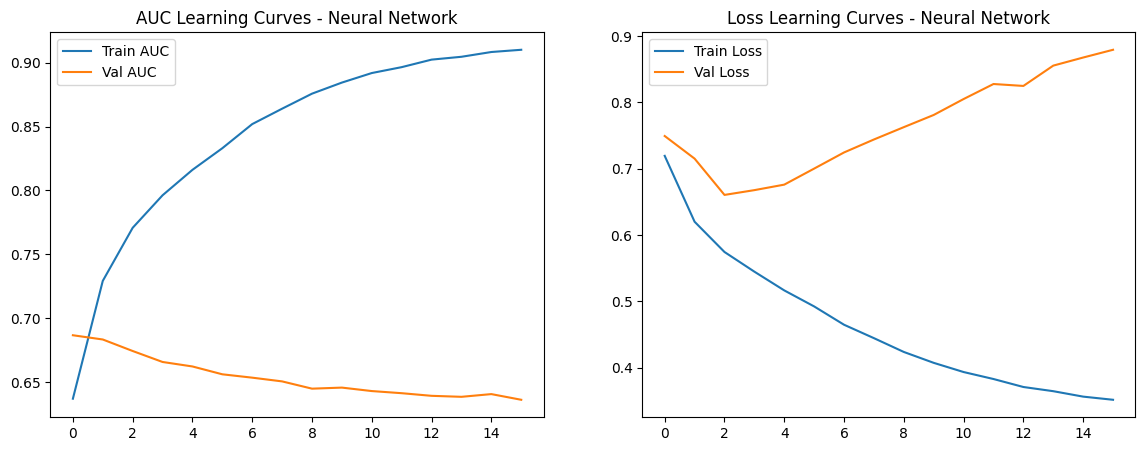

651/651 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

=== Neural Network RESULTS ===
              precision    recall  f1-score   support

           0     0.9612    0.1303    0.2295     16920
           1     0.2062    0.9772    0.3406      3912

    accuracy                         0.2894     20832
   macro avg     0.5837    0.5538    0.2850     20832
weighted avg     0.8194    0.2894    0.2504     20832



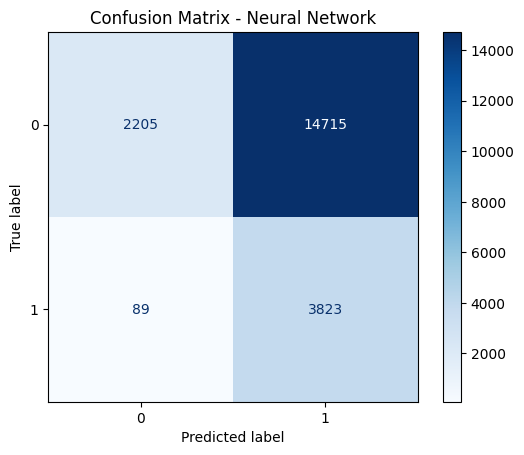

ROC-AUC: 0.6870


In [57]:
def build_nn(input_dim, neurons=128, n_layers=2, activation="relu", 
             dropout=0.3, lr=0.0005, use_bn=True, regularization=None):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    for _ in range(n_layers):
        model.add(layers.Dense(neurons, activation=activation, kernel_regularizer=regularization))
        if use_bn:
            model.add(BatchNormalization())
        model.add(layers.Dropout(dropout))
    
    model.add(layers.Dense(1, activation="sigmoid"))
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss="binary_crossentropy",
                  metrics=["accuracy", keras.metrics.AUC(name="auc")])
    return model

nn_model = build_nn(X_train_pp.shape[1])
early_stop = EarlyStopping(monitor="val_auc", patience=15, restore_best_weights=True, mode="max")
history = nn_model.fit(
    X_train_pp, y_train,
    validation_data=(X_test_pp, y_test),
    epochs=120,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Val AUC")
plt.title("AUC Learning Curves - Neural Network")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Learning Curves - Neural Network")
plt.legend()
plt.show()

y_proba_nn = nn_model.predict(X_test_pp).flatten()
y_pred_nn = (y_proba_nn > 0.5).astype(int)
evaluate_model(y_test, y_pred_nn, y_proba_nn, "Neural Network")

In [56]:
def build_and_train_for_tuning(neurons=128, n_layers=2, activation="relu", dropout=0.3, 
                               lr=0.0005, use_bn=True, regularization=None):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_pp.shape[1],)))
    
    reg = regularization  # None or l1/l2/l1_l2
    
    for _ in range(n_layers):
        model.add(layers.Dense(neurons, activation=activation, kernel_regularizer=reg))
        if use_bn:
            model.add(BatchNormalization())
        model.add(layers.Dropout(dropout))
    
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    
    early_stop = EarlyStopping(monitor='val_auc', patience=12, restore_best_weights=True, mode='max')
    
    history = model.fit(X_train_pp, y_train, validation_data=(X_test_pp, y_test),
                        epochs=100, batch_size=512, class_weight=class_weight_dict,
                        callbacks=[early_stop], verbose=0)
    
    y_proba = model.predict(X_test_pp, verbose=0).flatten()
    y_pred = (y_proba > 0.5).astype(int)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    return model, f1, auc, history

Now like before I'd like to experiment with regularisation.

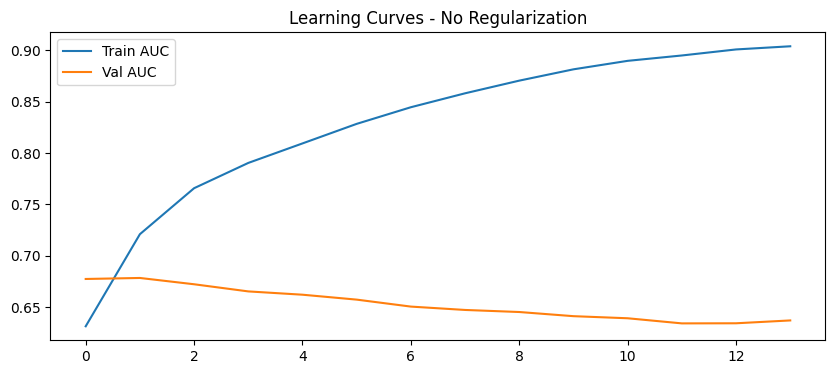

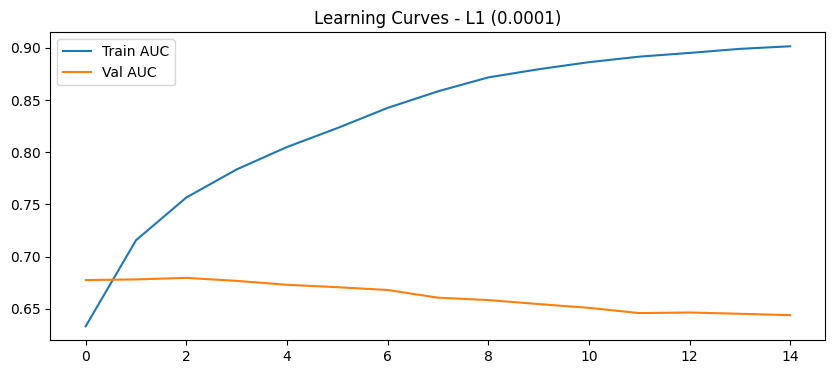

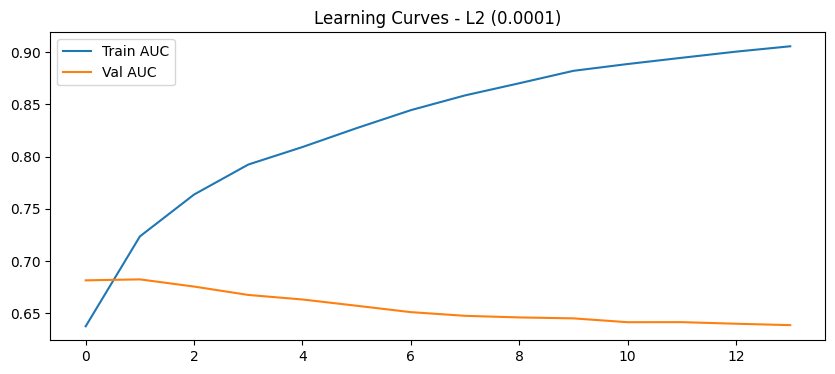

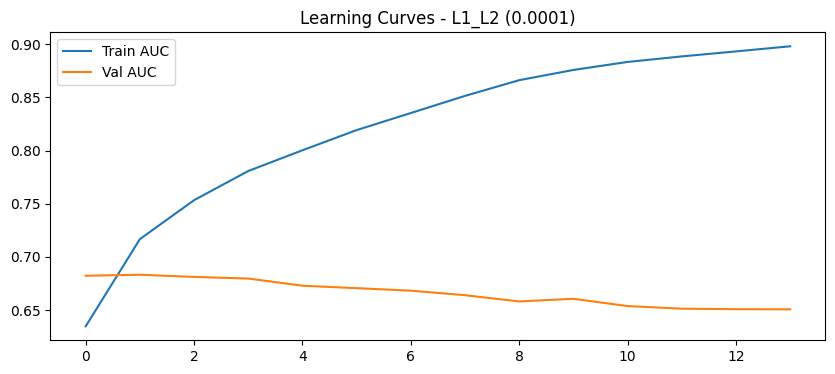

,Regularization,F1,ROC-AUC
0,No Regularization,0.3794,0.6783
1,L1 (0.0001),0.3847,0.6796
2,L2 (0.0001),0.1512,0.6825
3,L1_L2 (0.0001),0.3363,0.6831


In [32]:
from tensorflow.keras.regularizers import l1, l2, l1_l2

reg_candidates = [
    ("No Regularization", None),
    ("L1 (0.0001)", l1(0.0001)),
    ("L2 (0.0001)", l2(0.0001)),
    ("L1_L2 (0.0001)", l1_l2(l1=0.0001, l2=0.0001))
]

reg_results = []
for name, reg in reg_candidates:
    model, f1, auc, hist = build_and_train_for_tuning(regularization=reg)
    
    reg_results.append({"Regularization": name, "F1": round(f1,4), "ROC-AUC": round(auc,4)})
    
    plt.figure(figsize=(10,4))
    plt.plot(hist.history['auc'], label='Train AUC')
    plt.plot(hist.history['val_auc'], label='Val AUC')
    plt.title(f'Learning Curves - {name}')
    plt.legend()
    plt.show()

display(pd.DataFrame(reg_results))

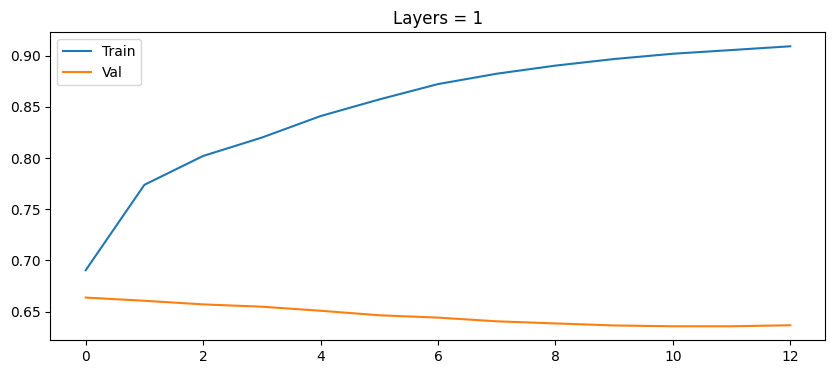

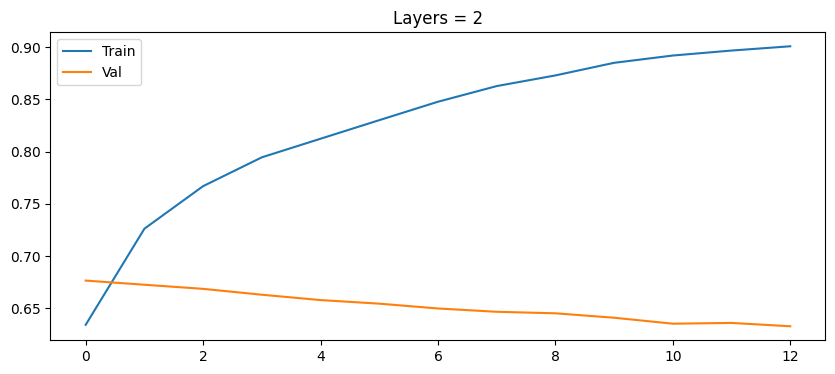

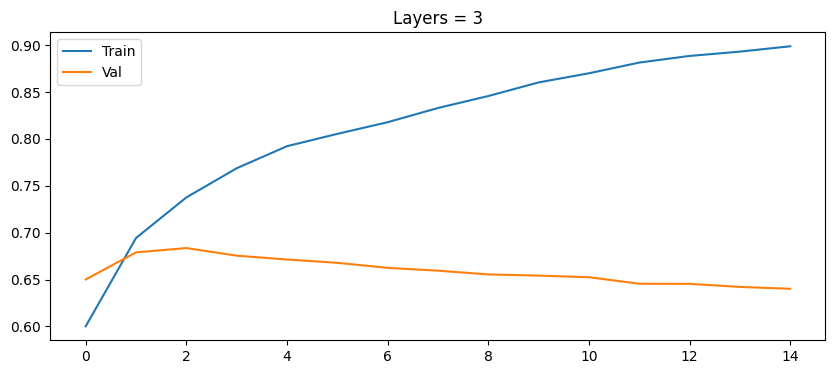

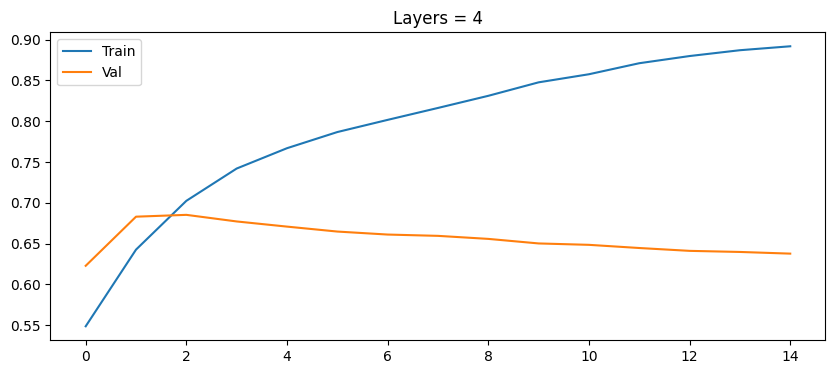

,Layers,F1,ROC-AUC
0,1,0.0086,0.6641
1,2,0.3231,0.6771
2,3,0.3926,0.6834
3,4,0.3949,0.6853


In [33]:
layer_results = []
for n_layers in [1, 2, 3, 4]:
    _, f1, auc, hist = build_and_train_for_tuning(n_layers=n_layers)
    layer_results.append({"Layers": n_layers, "F1": f1, "ROC-AUC": auc})
    
    plt.figure(figsize=(10,4))
    plt.plot(hist.history['auc'], label='Train')
    plt.plot(hist.history['val_auc'], label='Val')
    plt.title(f'Layers = {n_layers}')
    plt.legend()
    plt.show()

pd.DataFrame(layer_results).round(4)

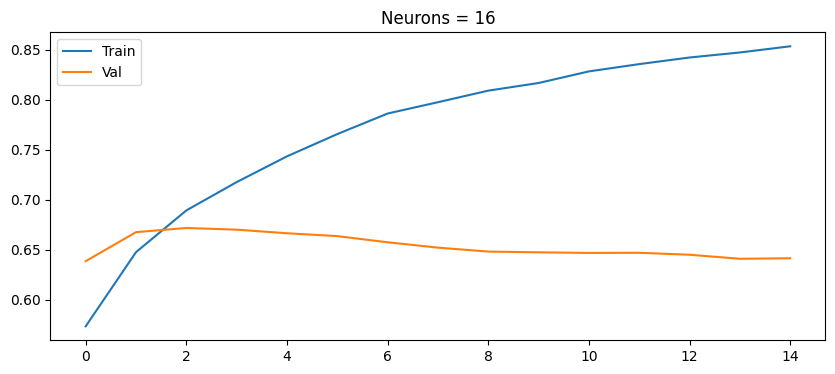

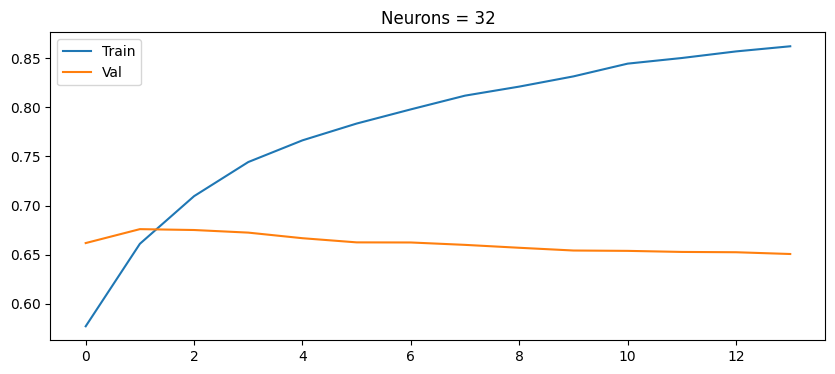

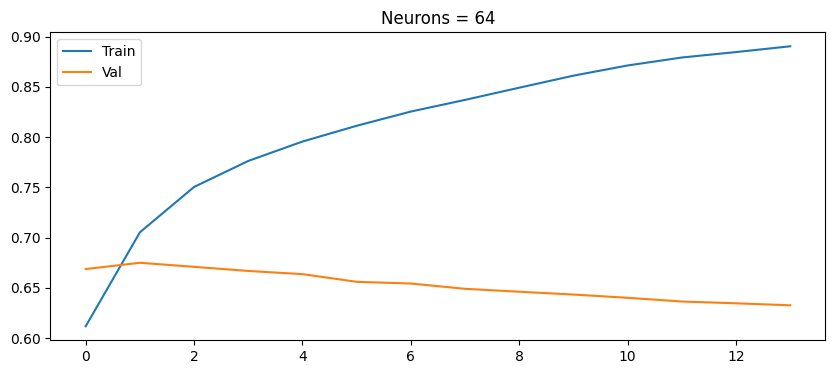

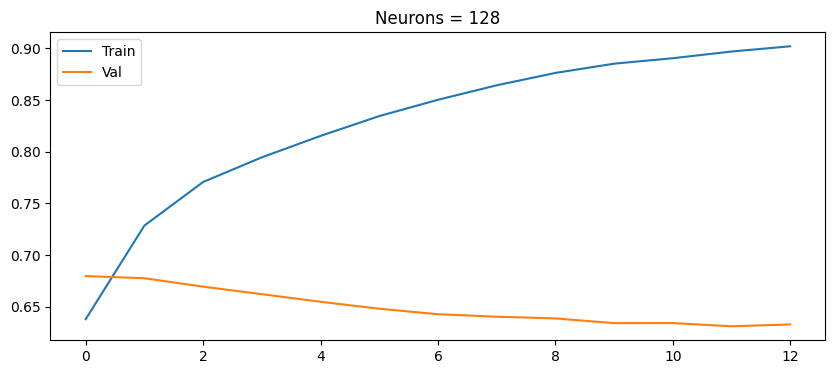

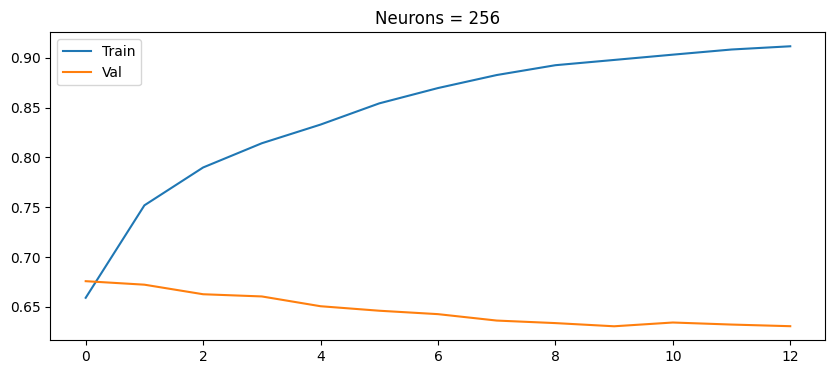

,Neurons,F1,ROC-AUC
0,16,0.3890,0.6717
1,32,0.3852,0.6759
2,64,0.3212,0.6750
3,128,0.3015,0.6798
4,256,0.3335,0.6761


In [35]:
neuron_results = []

for n_neurons in [16, 32, 64, 128, 256]:
    _, f1, auc, hist = build_and_train_for_tuning(neurons=n_neurons)
    
    neuron_results.append({
        "Neurons": n_neurons,
        "F1": f1,
        "ROC-AUC": auc
    })
    
    plt.figure(figsize=(10,4))
    plt.plot(hist.history['auc'], label='Train')
    plt.plot(hist.history['val_auc'], label='Val')
    plt.title(f'Neurons = {n_neurons}')
    plt.legend()
    plt.show()

pd.DataFrame(neuron_results).round(4)

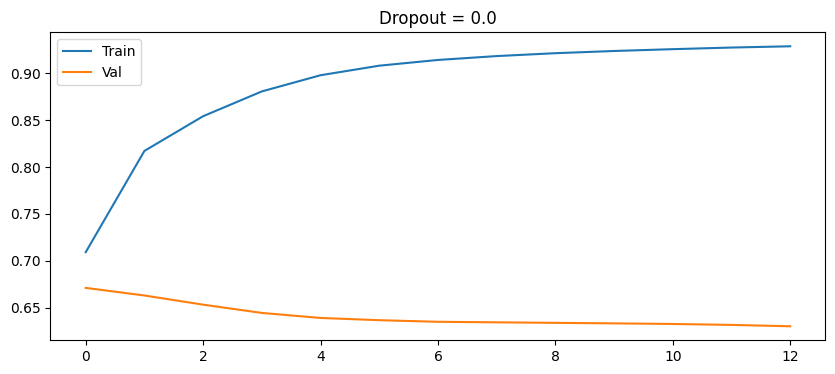

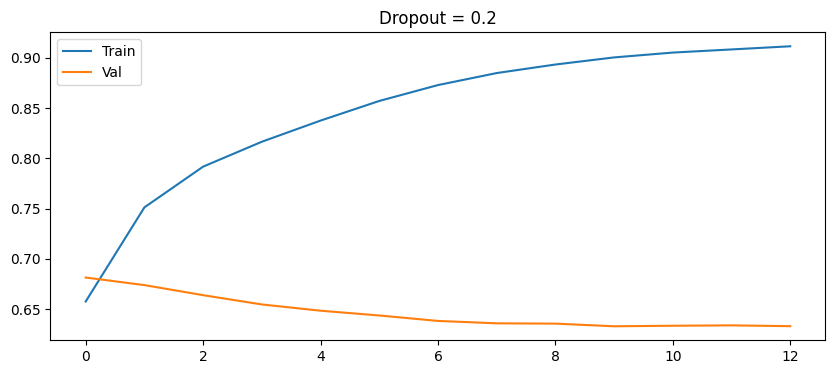

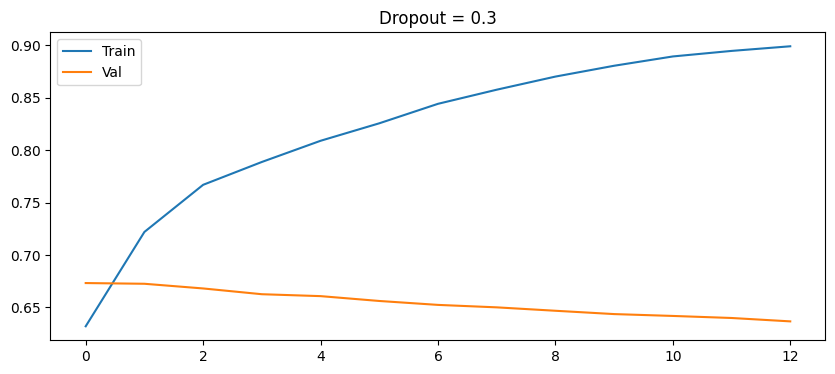

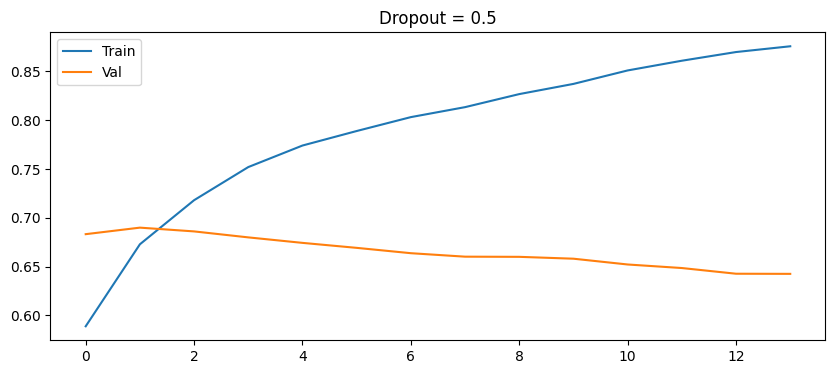

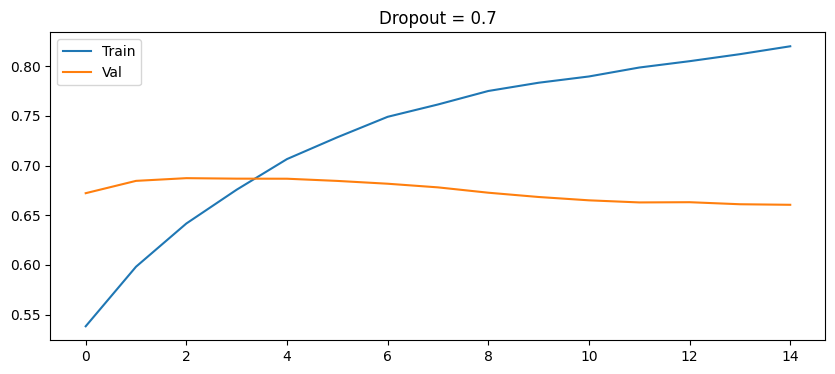

,Dropout,F1,ROC-AUC
0,0.0,0.3166,0.6716
1,0.2,0.0000,0.6821
2,0.3,0.1020,0.6735
3,0.5,0.3251,0.6900
4,0.7,0.3941,0.6871


In [36]:
dropout_results = []

for dropout in [0.0, 0.2, 0.3, 0.5, 0.7]:
    _, f1, auc, hist = build_and_train_for_tuning(dropout=dropout)
    
    dropout_results.append({
        "Dropout": dropout,
        "F1": f1,
        "ROC-AUC": auc
    })
    
    plt.figure(figsize=(10,4))
    plt.plot(hist.history['auc'], label='Train')
    plt.plot(hist.history['val_auc'], label='Val')
    plt.title(f'Dropout = {dropout}')
    plt.legend()
    plt.show()

pd.DataFrame(dropout_results).round(4)

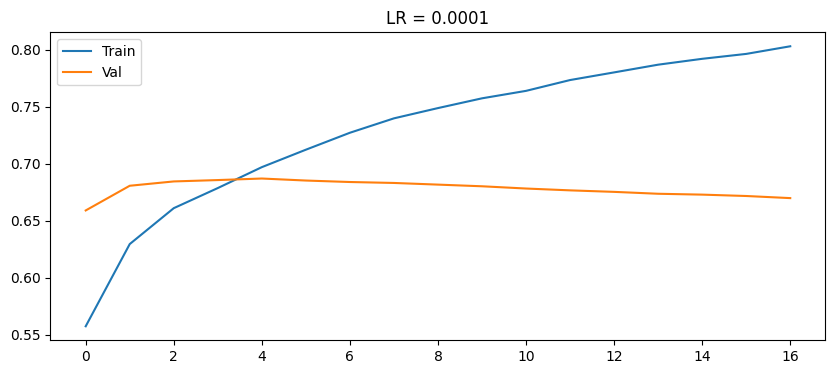

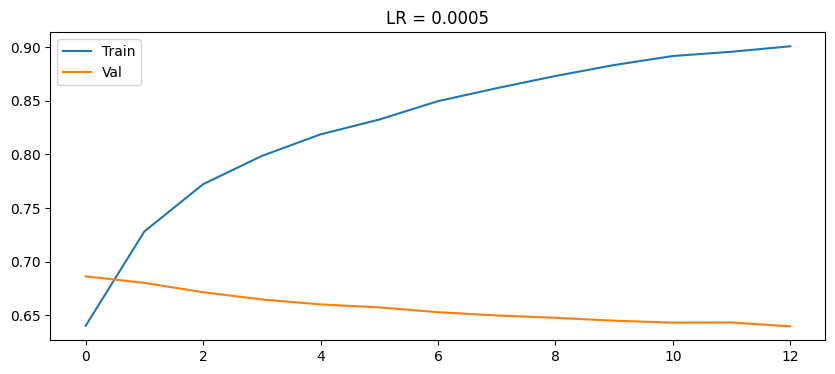

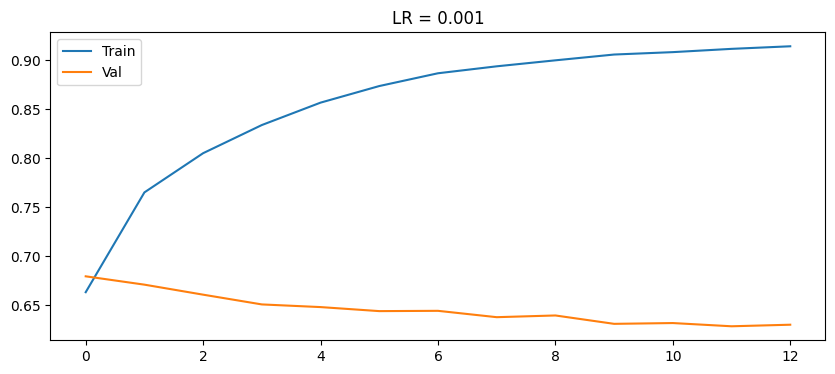

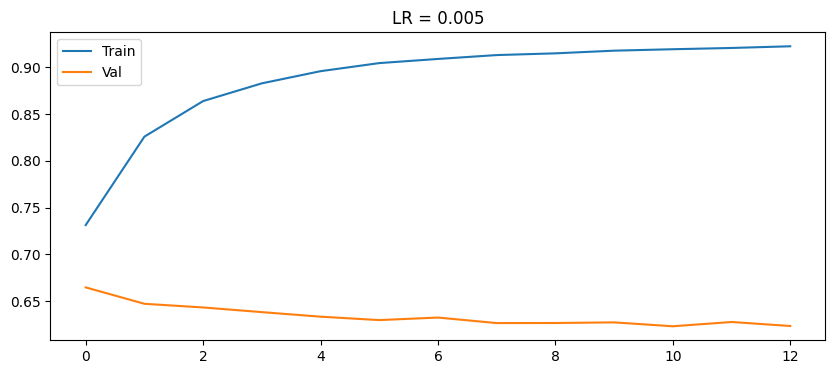

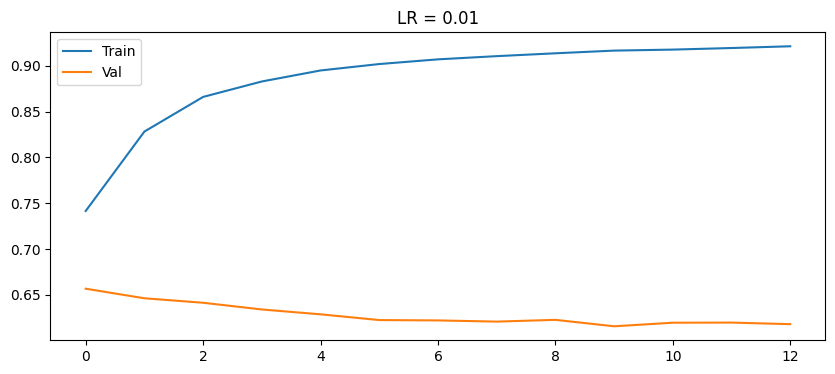

,Learning Rate,F1,ROC-AUC
0,0.0001,0.3875,0.6870
1,0.0005,0.0506,0.6864
2,0.0010,0.0126,0.6795
3,0.0050,0.3820,0.6648
4,0.0100,0.3053,0.6566


In [38]:
lr_results = []

for lr in [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]:
    _, f1, auc, hist = build_and_train_for_tuning(lr=lr)
    
    lr_results.append({
        "Learning Rate": lr,
        "F1": f1,
        "ROC-AUC": auc
    })
    
    plt.figure(figsize=(10,4))
    plt.plot(hist.history['auc'], label='Train')
    plt.plot(hist.history['val_auc'], label='Val')
    plt.title(f'LR = {lr}')
    plt.legend()
    plt.show()

pd.DataFrame(lr_results).round(4)

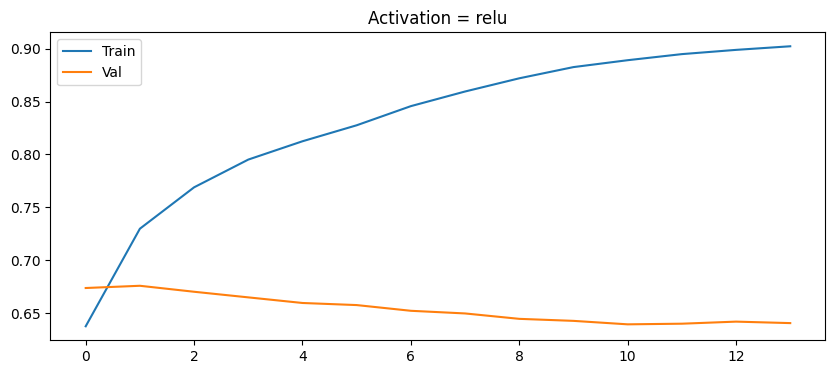

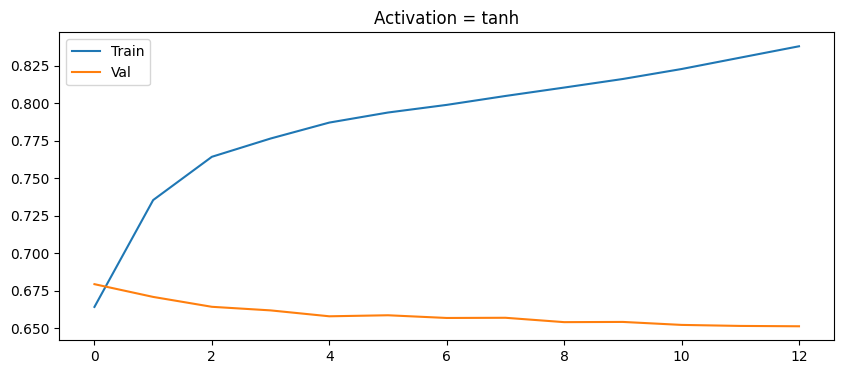

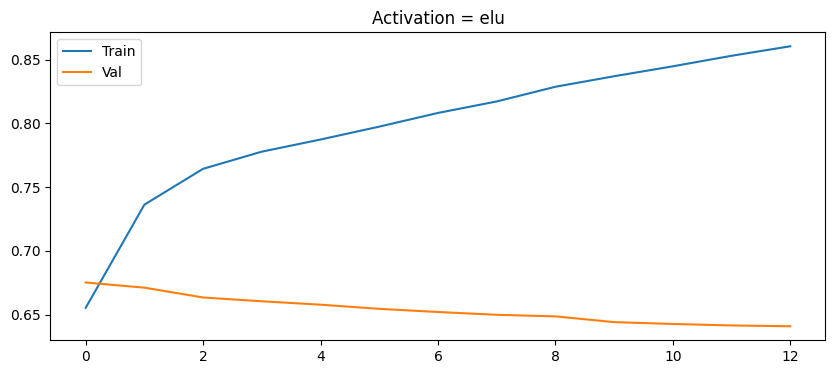

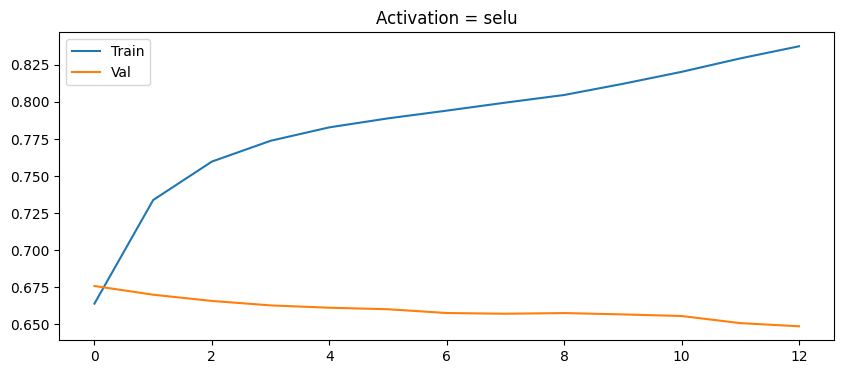

,Activation,F1,ROC-AUC
0,relu,0.2466,0.6758
1,tanh,0.3148,0.6794
2,elu,0.3208,0.6752
3,selu,0.3250,0.6760


In [40]:
activation_results = []

for activation in ['relu', 'tanh', 'elu', 'selu']:
    _, f1, auc, hist = build_and_train_for_tuning(activation=activation)
    
    activation_results.append({
        "Activation": activation,
        "F1": f1,
        "ROC-AUC": auc
    })
    
    plt.figure(figsize=(10,4))
    plt.plot(hist.history['auc'], label='Train')
    plt.plot(hist.history['val_auc'], label='Val')
    plt.title(f'Activation = {activation}')
    plt.legend()
    plt.show()

pd.DataFrame(activation_results).round(4)

Now, I'd also like to carry out experiment with TabNet

/home/sofia/stored_data/ggsn/venvvv/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 302: Error loading CUDA libraries. GPU will not be used. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
/home/sofia/stored_data/ggsn/venvvv/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.53389 | val_0_auc: 0.5185  |  0:00:13s
epoch 1  | loss: 0.46709 | val_0_auc: 0.53933 |  0:00:25s
epoch 2  | loss: 0.4606  | val_0_auc: 0.56811 |  0:00:43s
epoch 3  | loss: 0.44733 | val_0_auc: 0.64191 |  0:00:59s
epoch 4  | loss: 0.42875 | val_0_auc: 0.65977 |  0:01:16s
epoch 5  | loss: 0.41396 | val_0_auc: 0.66434 |  0:01:33s
epoch 6  | loss: 0.40107 | val_0_auc: 0.65619 |  0:01:49s
epoch 7  | loss: 0.39235 | val_0_auc: 0.65317 |  0:02:07s
epoch 8  | loss: 0.38359 | val_0_auc: 0.64858 |  0:02:24s
epoch 9  | loss: 0.37476 | val_0_auc: 0.64434 |  0:02:41s
epoch 10 | loss: 0.36674 | val_0_auc: 0.63472 |  0:02:57s
epoch 11 | loss: 0.35523 | val_0_auc: 0.63365 |  0:03:14s
epoch 12 | loss: 0.34273 | val_0_auc: 0.63068 |  0:03:32s

Early stopping occurred at epoch 12 with best_epoch = 5 and best_val_0_auc = 0.66434


/home/sofia/stored_data/ggsn/venvvv/lib/python3.10/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



=== TabNet RESULTS ===
              precision    recall  f1-score   support

           0     0.8121    0.9986    0.8958     16920
           1     0.0800    0.0005    0.0010      3912

    accuracy                         0.8112     20832
   macro avg     0.4460    0.4996    0.4484     20832
weighted avg     0.6746    0.8112    0.7277     20832



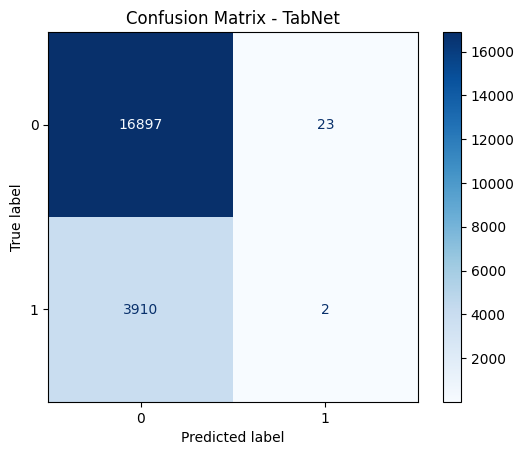

ROC-AUC: 0.6643


In [44]:
tabnet = TabNetClassifier(
    n_d=16, n_a=16, n_steps=3, gamma=1.3,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.02),
    verbose=1
)

tabnet.fit(
    X_train_pp.toarray() if hasattr(X_train_pp, "toarray") else X_train_pp,
    y_train.values,
    eval_set=[(X_test_pp.toarray() if hasattr(X_test_pp, "toarray") else X_test_pp, y_test.values)],
    max_epochs=25,
    batch_size=1024,
    virtual_batch_size=128,
    patience=7
)

y_pred_tab = tabnet.predict(X_test_pp.toarray() if hasattr(X_test_pp, "toarray") else X_test_pp)
y_proba_tab = tabnet.predict_proba(X_test_pp.toarray() if hasattr(X_test_pp, "toarray") else X_test_pp)[:, 1]

evaluate_model(y_test, y_pred_tab, y_proba_tab, "TabNet")

After some experimenting I'd like to focus on XGBoost, as it is the best fitting model so far.
(one-by-one hyperparameter tuning, as has been done before)

In [48]:
xgb_tuning_results = []

base_params = {
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.08,
    'scale_pos_weight': pos_weight,
    'random_state': SEED,
    'eval_metric': 'auc'
}

for n_est in [100, 200, 300, 400, 500]:
    params = base_params.copy()
    params['n_estimators'] = n_est
    model = XGBClassifier(**params)
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    f1 = f1_score(y_test, pipe.predict(X_test))
    auc = roc_auc_score(y_test, y_proba)
    xgb_tuning_results.append({'param': 'n_estimators', 'value': n_est, 'F1': round(f1,4), 'ROC-AUC': round(auc,4)})

for depth in [3, 4, 5, 6, 7, 8]:
    params = base_params.copy()
    params['max_depth'] = depth
    model = XGBClassifier(**params)
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    f1 = f1_score(y_test, pipe.predict(X_test))
    auc = roc_auc_score(y_test, y_proba)
    xgb_tuning_results.append({'param': 'max_depth', 'value': depth, 'F1': round(f1,4), 'ROC-AUC': round(auc,4)})

for lr in [0.01, 0.05, 0.08, 0.1, 0.15]:
    params = base_params.copy()
    params['learning_rate'] = lr
    model = XGBClassifier(**params)
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    f1 = f1_score(y_test, pipe.predict(X_test))
    auc = roc_auc_score(y_test, y_proba)
    xgb_tuning_results.append({'param': 'learning_rate', 'value': lr, 'F1': round(f1,4), 'ROC-AUC': round(auc,4)})

tuning_df = pd.DataFrame(xgb_tuning_results)
display(tuning_df.sort_values('F1', ascending=False).head(10))

print("\nBest configurations found during tuning:")
display(tuning_df.groupby('param').apply(lambda x: x.loc[x['F1'].idxmax()]))

,param,value,F1,ROC-AUC
9,max_depth,7.00,0.5368,0.8614
10,max_depth,8.00,0.5362,0.8624
3,n_estimators,400.00,0.5340,0.8580
2,n_estimators,300.00,0.5336,0.8585
13,learning_rate,0.08,0.5336,0.8585
8,max_depth,6.00,0.5336,0.8585
4,n_estimators,500.00,0.5336,0.8568
15,learning_rate,0.15,0.5336,0.8577
1,n_estimators,200.00,0.5329,0.8593
14,learning_rate,0.10,0.5328,0.8577



Best configurations found during tuning:


/tmp/ipykernel_17901/513696094.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(tuning_df.groupby('param').apply(lambda x: x.loc[x['F1'].idxmax()]))


,param,value,F1,ROC-AUC
param,,,,
learning_rate,learning_rate,0.08,0.5336,0.8585
max_depth,max_depth,7.00,0.5368,0.8614
n_estimators,n_estimators,400.00,0.5340,0.8580


Training final XGBoost model with optimized parameters...

=== FINAL XGBoost Model RESULTS ===
              precision    recall  f1-score   support

           0     0.9374    0.7359    0.8246     16920
           1     0.4081    0.7876    0.5376      3912

    accuracy                         0.7456     20832
   macro avg     0.6728    0.7618    0.6811     20832
weighted avg     0.8380    0.7456    0.7707     20832



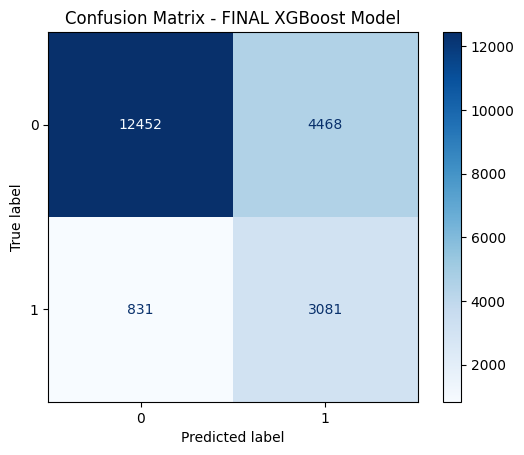

ROC-AUC: 0.8614


In [49]:
# best combination
final_xgb_params = {
    'n_estimators': 400,
    'max_depth': 7,
    'learning_rate': 0.08,
    'scale_pos_weight': pos_weight,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': SEED,
    'eval_metric': 'auc'
}

final_xgb = XGBClassifier(**final_xgb_params)

final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', final_xgb)
])

print("Training final XGBoost model with optimized parameters...")
final_pipe.fit(X_train, y_train)

y_pred_final = final_pipe.predict(X_test)
y_proba_final = final_pipe.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred_final, y_proba_final, "FINAL XGBoost Model")

best_model = final_pipe.named_steps['classifier']

SHAP Explainability

SHAP Summary Plot


/tmp/ipykernel_17901/2348789955.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample_df)


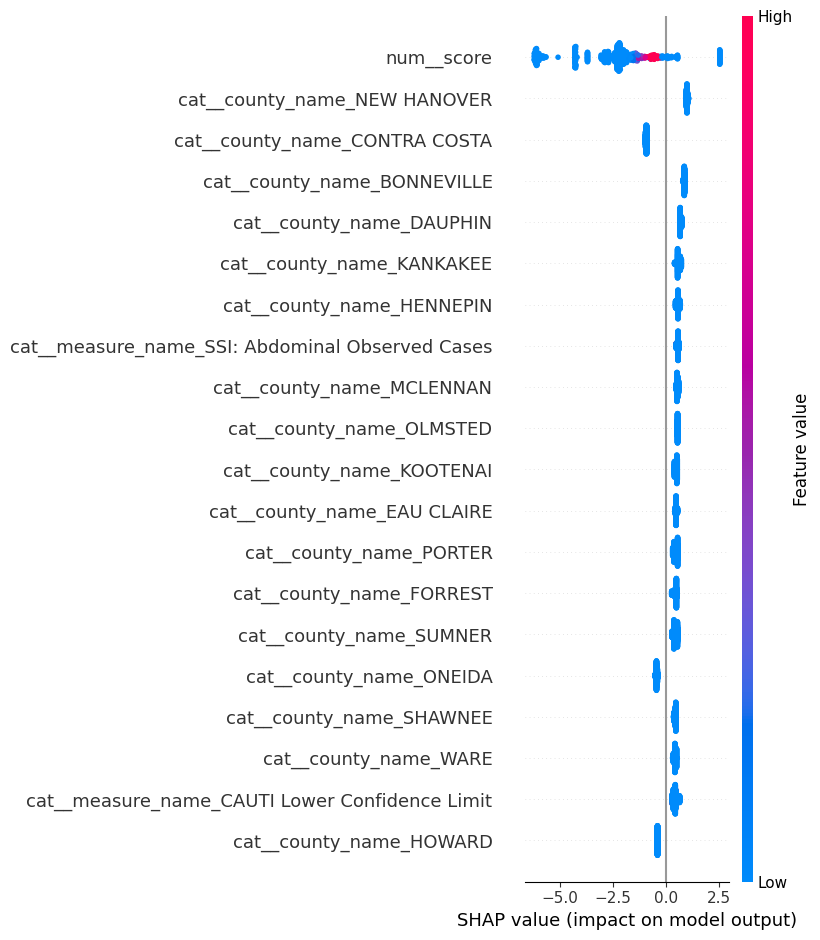

In [52]:
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)
selector = VarianceThreshold(threshold=0.0)
X_train_sel = selector.fit_transform(X_train_pre)
X_test_sel = selector.transform(X_test_pre)
all_feature_names = preprocessor.get_feature_names_out()
selected_mask = selector.get_support()
selected_feature_names = all_feature_names[selected_mask]

X_sample = X_test_sel[:800]
if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()

X_sample_df = pd.DataFrame(X_sample, columns=selected_feature_names)

explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_sample_df)

print("SHAP Summary Plot")
shap.summary_plot(shap_values, X_sample_df)

Predictably, score has the biggest influence on the decision, county names and certain measure names can also be important.

SHAP Global Feature Importance


/tmp/ipykernel_17901/3778299363.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample_df, plot_type="bar")


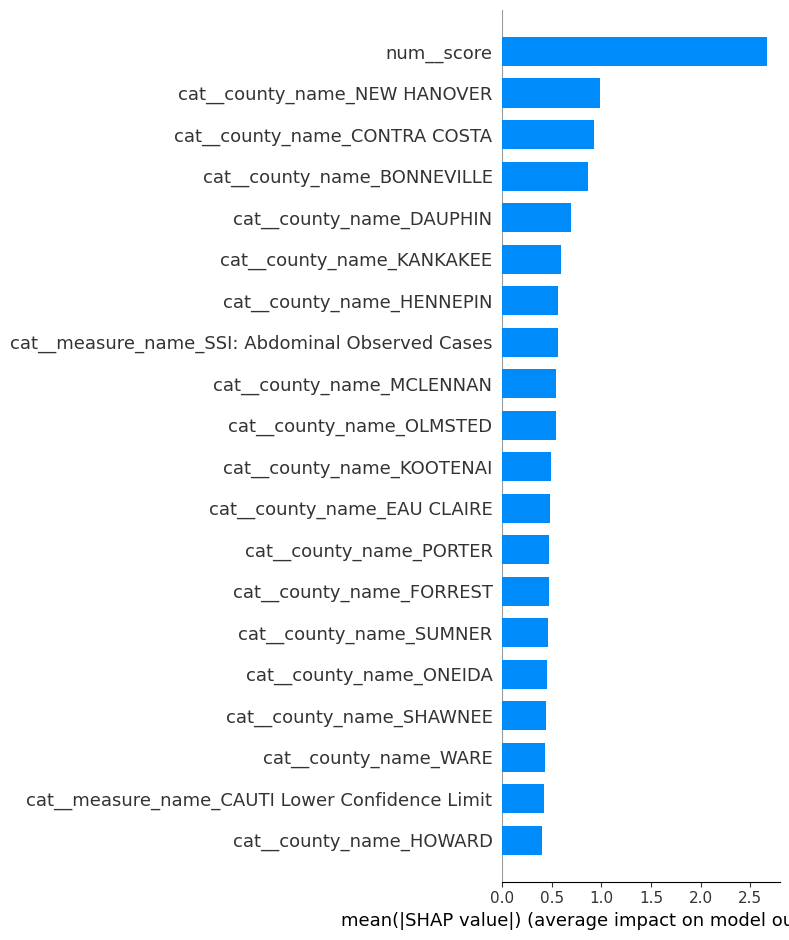

In [53]:
print("SHAP Global Feature Importance")
shap.summary_plot(shap_values, X_sample_df, plot_type="bar")

Analysis of misclassified samples

In [61]:
y_pred_final = final_pipe.predict(X_test)
mis_idx = np.where(y_pred_final != y_test.values)[0]

mis_df = X_test.iloc[mis_idx[:15]].copy()
mis_df["true_label"] = y_test.iloc[mis_idx[:15]].values
mis_df["predicted_label"] = y_pred_final[mis_idx[:15]]
mis_df["score"] = pd.to_numeric(mis_df["score"], errors="coerce")

display(mis_df)

print(f"Average score in misclassified cases : {mis_df['score'].mean():.2f}")
print(f"Average score in all test cases      : {X_test['score'].mean():.2f}")
print(f"Proportion of 'better' class in misclassified: {(mis_df['true_label'].mean()*100):.1f}%")

,state,measure_name,measure_id,county_name,score,true_label,predicted_label
108,AK,CLABSI: Observed Cases,HAI_1_NUMERATOR,ANCHORAGE,4.000,1,0
120,AK,CAUTI: Lower Confidence Limit,HAI_2_CI_LOWER,ANCHORAGE,0.355,0,1
122,AK,CAUTI: Number of Procedures,HAI_2_DOPC_DAYS,ANCHORAGE,4658.000,0,1
123,AK,CAUTI: Predicted Cases,HAI_2_ELIGCASES,ANCHORAGE,6.848,0,1
124,AK,CAUTI: Observed Cases,HAI_2_NUMERATOR,ANCHORAGE,6.000,0,1
128,AK,CAUTI Urinary Catheter Days,HAI_2a_DOPC_DAYS,ANCHORAGE,6185.000,0,1
129,AK,CAUTI Predicted Cases,HAI_2a_ELIGCASES,ANCHORAGE,9.188,0,1
185,AR,CLABSI: Number of Procedures,HAI_1_DOPC_DAYS,PULASKI,12118.000,0,1
186,AR,CLABSI: Predicted Cases,HAI_1_ELIGCASES,PULASKI,21.635,0,1
187,AR,CLABSI: Observed Cases,HAI_1_NUMERATOR,PULASKI,30.000,0,1


Average score in misclassified cases : 3907.07
Average score in all test cases      : 3451.39
Proportion of 'better' class in misclassified: 13.3%


The dominant error type is false positives for the 'better' class. At the same time, there are relatively few false negatives indicating a bias toward predicting better performance.

Misclassified observations also have higher average scores, suggesting the model tends to associate larger values with 'better' outcomes, even when that relationship does not hold consistently across different measure types.

To sum up:
- After changing preprocessing approach and adding group-aware validation it became obvious that **XGBoost** is the best model for my task (F1≈0.54, ROC-AUC≈0.86).

- The most impactfull feature was score (and rightfully so).

- If a case gets missclassified, it's highly likely that it is the model marking regular/worse performance as a better one.